In [1]:
import numpy as np
from datetime import datetime, timedelta
from ordered_set import OrderedSet
from stonesoup.types.groundtruth import GroundTruthPath, GroundTruthState
from stonesoup.models.transition.linear import CombinedLinearGaussianTransitionModel, ConstantVelocity
from stonesoup.models.measurement.linear import LinearGaussian
from stonesoup.types.detection import TrueDetection, Clutter
from stonesoup.types.state import GaussianState
from stonesoup.types.track import Track
from stonesoup.types.array import StateVectors
from stonesoup.functions import gm_reduce_single
from stonesoup.types.update import GaussianStateUpdate

from stonesoup.predictor.kalman import KalmanPredictor
from stonesoup.updater.kalman import KalmanUpdater
from stonesoup.hypothesiser.probability import PDAHypothesiser
from stonesoup.dataassociator.probability import JPDAwithLBP as JPDA
from stonesoup.initiator.simple import MultiMeasurementInitiator
from stonesoup.deleter.time import UpdateTimeDeleter
from stonesoup.tracker.simple import MultiTargetTracker

    # 1. Create ground truth
def generate_siap_metrics(seed, num_steps):
    np.random.seed(seed)
    start_time = datetime.now().replace(microsecond=0)
    timesteps = [start_time + timedelta(seconds=k) for k in range(num_steps + 1)]

    transition_model = CombinedLinearGaussianTransitionModel([ConstantVelocity(0.005), ConstantVelocity(0.005)])

    truths = OrderedSet()
    truth1 = GroundTruthPath([GroundTruthState([0, 1, 0, 1], timestamp=timesteps[0])])
    for k in range(1, num_steps + 1):
        truth1.append(GroundTruthState(
            transition_model.function(truth1[k-1], noise=True, time_interval=timedelta(seconds=1)),
            timestamp=timesteps[k]))
    truths.add(truth1)

    truth2 = GroundTruthPath([GroundTruthState([0, 1, 20, -1], timestamp=timesteps[0])])
    for k in range(1, num_steps + 1):
        truth2.append(GroundTruthState(
            transition_model.function(truth2[k-1], noise=True, time_interval=timedelta(seconds=1)),
            timestamp=timesteps[k]))
    truths.add(truth2)

    # 2. Generate measurements (with clutter)
    all_measurements = []
    measurement_model = LinearGaussian(
        ndim_state=4,
        mapping=(0, 2),
        noise_covar=np.array([[15, 0],
                            [0, 15]])
        )
    prob_detect = 0.90

    for k in range(num_steps + 1):
        measurement_set = set()
        for truth in truths:
            # True detection with prob_detect
            if np.random.rand() <= prob_detect:
                measurement = measurement_model.function(truth[k], noise=True)
                measurement_set.add(TrueDetection(
                    state_vector=measurement,
                    groundtruth_path=truth,
                    timestamp=truth[k].timestamp,
                    measurement_model=measurement_model))
            # Add random clutter (simulate "hard" tracking scenario)
            for _ in range(np.random.randint(2)):
                x = np.random.uniform(-10, 30)
                y = np.random.uniform(-10, 30)
                measurement_set.add(Clutter(
                    np.array([[x], [y]]),
                    timestamp=truth[k].timestamp,
                    measurement_model=measurement_model
                ))
        all_measurements.append(measurement_set)

    # 3. Create tracking components (JPDA)
    predictor = KalmanPredictor(transition_model)
    updater = KalmanUpdater(measurement_model)
    hypothesiser = PDAHypothesiser(
        predictor=predictor,
        updater=updater,
        clutter_spatial_density=0.125,
        prob_detect=prob_detect,
        prob_gate=0.999
    )
    data_associator = JPDA(hypothesiser=hypothesiser)

    # Initiator: needs a prior (wide covar) and a deleter for tracks
    prior_state = GaussianState([[0], [1], [0], [1]], np.diag([100, 25, 100, 25]), timestamp=start_time)
    deleter = UpdateTimeDeleter(time_since_update=timedelta(seconds=20))
    initiator = MultiMeasurementInitiator(
        prior_state=prior_state,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        measurement_model=measurement_model,
        min_points=1
    )

    detector = iter(list(zip(timesteps, all_measurements)))
    # 4. Tracker
    tracker = MultiTargetTracker(
        initiator=initiator,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        detector=detector
    )

    # 5. Run tracking
    tracks = set()
    for time, curr_tracks in tracker:
        tracks |= curr_tracks

    # Filter out very short tracks (common in SIAP metric evaluations)
    tracks = {track for track in tracks if len(track) > 3}
    tracks = set(tracks)

    # 6. Evaluate SIAP metrics (optional, if you want, requires stonesoup.metricgenerator)


    from stonesoup.metricgenerator.tracktotruthmetrics import SIAPMetrics
    from stonesoup.measures import Euclidean
    from stonesoup.metricgenerator.manager import MultiManager
    from stonesoup.dataassociator.tracktotrack import TrackToTruth

    associator_eval = TrackToTruth(association_threshold=30)

    siap_metrics = SIAPMetrics(
            position_measure=Euclidean((0,2)),
            velocity_measure=Euclidean((1,3)),
            generator_name='SIAP',
            tracks_key='tracks',
            truths_key='truths'
        )
    metric_manager = MultiManager([siap_metrics], associator=associator_eval)
    metric_manager.add_data({'tracks': tracks}, overwrite=False)
    metric_manager.add_data({'truths': truths}, overwrite=False)
    metrics = metric_manager.generate_metrics()
    siap_result = metrics['SIAP']

    spuriousness = siap_result.get('SIAP Spuriousness').value
    ambiguity = siap_result.get('SIAP Ambiguity').value
    completeness = siap_result.get('SIAP Completeness').value
    position_accuracy = siap_result.get('SIAP Position Accuracy').value
    velocity_accuracy = siap_result.get('SIAP Velocity Accuracy').value
    rate_track_change = siap_result.get('SIAP Rate of Track Number Change').value
    longest_track = siap_result.get('SIAP Longest Track Segment').value
    spuriousness_at_times = siap_result.get('SIAP Spuriousness at times').value
    ambiguity_at_times = siap_result.get('SIAP Ambiguity at times').value
    completeness_at_times = siap_result.get('SIAP Completeness at times').value
    position_accuracy_at_times = siap_result.get('SIAP Position Accuracy at times').value
    velocity_accuracy_at_times = siap_result.get('SIAP Velocity Accuracy at times').value
   
    """
    print("Position Accuracy:", position_accuracy)
    print("Velocity Accuracy:", velocity_accuracy)
    print("Spuriousness:", spuriousness)
    print("Ambiguity:", ambiguity)
    """

    return spuriousness, ambiguity, completeness, position_accuracy, velocity_accuracy, rate_track_change, longest_track,\
            spuriousness_at_times, ambiguity_at_times, completeness_at_times, position_accuracy_at_times, velocity_accuracy_at_times


In [2]:
"""
import numpy as np
from datetime import datetime, timedelta
from ordered_set import OrderedSet
from StoneSoupID.stonesoupID.types.groundtruth import GroundTruthPath, GroundTruthState
from StoneSoupID.stonesoupID.models.transition.linear import CombinedLinearGaussianTransitionModel, ConstantVelocity
from StoneSoupID.stonesoupID.models.measurement.linear import LinearGaussian
from StoneSoupID.stonesoupID.types.detection import TrueDetection, Clutter
from StoneSoupID.stonesoupID.types.state import GaussianState
from StoneSoupID.stonesoupID.types.track import Track
from StoneSoupID.stonesoupID.types.array import StateVectors
from StoneSoupID.stonesoupID.functions import gm_reduce_single
from StoneSoupID.stonesoupID.types.update import GaussianStateUpdate

from StoneSoupID.stonesoupID.predictor.kalman import KalmanPredictor as KalmanPredictorID
from StoneSoupID.stonesoupID.updater.kalman import KalmanUpdater as KalmanUpdaterID
from StoneSoupID.stonesoupID.hypothesiser.probability import PDAHypothesiser as PDAHypothesiserID
from StoneSoupID.stonesoupID.dataassociator.probability import JPDAwithLBP as JPDAID
from StoneSoupID.stonesoupID.initiator.simple import MultiMeasurementInitiator
from StoneSoupID.stonesoupID.deleter.time import UpdateTimeDeleter
from StoneSoupID.stonesoupID.tracker.simple import MultiTargetTracker

def generate_siap_metrics_id(seed, num_steps):
    # 1. Create ground truth
    np.random.seed(seed)
    start_time = datetime.now().replace(microsecond=0)
    timesteps = [start_time + timedelta(seconds=k) for k in range(num_steps + 1)]

    transition_model = CombinedLinearGaussianTransitionModel([ConstantVelocity(0.005), ConstantVelocity(0.005)])

    truths = OrderedSet()
    truth1 = GroundTruthPath([GroundTruthState([0, 1, 0, 1], timestamp=timesteps[0])])
    for k in range(1, num_steps + 1):
        truth1.append(GroundTruthState(
            transition_model.function(truth1[k-1], noise=True, time_interval=timedelta(seconds=1)),
            timestamp=timesteps[k]))
    truths.add(truth1)

    truth2 = GroundTruthPath([GroundTruthState([0, 1, 20, -1], timestamp=timesteps[0])])
    for k in range(1, num_steps + 1):
        truth2.append(GroundTruthState(
            transition_model.function(truth2[k-1], noise=True, time_interval=timedelta(seconds=1)),
            timestamp=timesteps[k]))
    truths.add(truth2)

    # 2. Generate measurements (with clutter)
    all_measurements = []
    measurement_model = LinearGaussian(
        ndim_state=4,
        mapping=(0, 2),
        noise_covar=np.array([[15, 0],
                            [0, 15]])
        )
    prob_detect = 0.90

    for k in range(num_steps + 1):
        measurement_set = set()
        for truth in truths:
            # True detection with prob_detect
            if np.random.rand() <= prob_detect:
                measurement = measurement_model.function(truth[k], noise=True)
                measurement_set.add(TrueDetection(
                    state_vector=measurement,
                    groundtruth_path=truth,
                    timestamp=truth[k].timestamp,
                    measurement_model=measurement_model))
            # Add random clutter (simulate "hard" tracking scenario)
            for _ in range(np.random.randint(2)):
                x = np.random.uniform(-10, 30)
                y = np.random.uniform(-10, 30)
                measurement_set.add(Clutter(
                    np.array([[x], [y]]),
                    timestamp=truth[k].timestamp,
                    measurement_model=measurement_model
                ))
        all_measurements.append(measurement_set)

    # 3. Create tracking components (JPDA)
    predictor = KalmanPredictorID(transition_model)
    updater = KalmanUpdaterID(measurement_model)
    hypothesiser = PDAHypothesiserID(
        predictor=predictor,
        updater=updater,
        clutter_spatial_density=0.125,
        prob_detect=prob_detect,
        prob_gate=0.999
    )
    data_associator = JPDAID(hypothesiser=hypothesiser)

    # Initiator: needs a prior (wide covar) and a deleter for tracks
    prior_state = GaussianState([[0], [1], [0], [1]], np.diag([100, 25, 100, 25]), timestamp=start_time)
    deleter = UpdateTimeDeleter(time_since_update=timedelta(seconds=20))
    initiator = MultiMeasurementInitiator(
        prior_state=prior_state,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        measurement_model=measurement_model,
        min_points=1
    )

    detector = iter(list(zip(timesteps, all_measurements)))
    # 4. Tracker
    tracker = MultiTargetTracker(
        initiator=initiator,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        detector=detector
    )

    # 5. Run tracking
    tracks = set()
    for time, curr_tracks in tracker:
        tracks |= curr_tracks

    # Filter out very short tracks (common in SIAP metric evaluations)
    tracks = {track for track in tracks if len(track) > 3}
    tracks = set(tracks)

    # 6. Evaluate SIAP metrics (optional, if you want, requires stonesoup.metricgenerator)


    from stonesoup.metricgenerator.tracktotruthmetrics import SIAPMetrics
    from stonesoup.measures import Euclidean
    from stonesoup.metricgenerator.manager import MultiManager
    from stonesoup.dataassociator.tracktotrack import TrackToTruth

    associator_eval = TrackToTruth(association_threshold=30)

    siap_metrics = SIAPMetrics(
            position_measure=Euclidean((0,2)),
            velocity_measure=Euclidean((1,3)),
            generator_name='SIAP',
            tracks_key='tracks',
            truths_key='truths'
        )
    metric_manager = MultiManager([siap_metrics], associator=associator_eval)
    metric_manager.add_data({'tracks': tracks}, overwrite=False)
    metric_manager.add_data({'truths': truths}, overwrite=False)
    metrics = metric_manager.generate_metrics()
    siap_result = metrics['SIAP']

    spuriousness = siap_result.get('SIAP Spuriousness').value
    ambiguity = siap_result.get('SIAP Ambiguity').value
    completeness = siap_result.get('SIAP Completeness').value
    position_accuracy = siap_result.get('SIAP Position Accuracy').value
    velocity_accuracy = siap_result.get('SIAP Velocity Accuracy').value
    rate_track_change = siap_result.get('SIAP Rate of Track Number Change').value
    longest_track = siap_result.get('SIAP Longest Track Segment').value
    spuriousness_at_times = siap_result.get('SIAP Spuriousness at times').value
    ambiguity_at_times = siap_result.get('SIAP Ambiguity at times').value
    completeness_at_times = siap_result.get('SIAP Completeness at times').value
    position_accuracy_at_times = siap_result.get('SIAP Position Accuracy at times').value
    velocity_accuracy_at_times = siap_result.get('SIAP Velocity Accuracy at times').value
   
    
    #print("Position Accuracy:", position_accuracy)
    #print("Velocity Accuracy:", velocity_accuracy)
    #print("Spuriousness:", spuriousness)
    #print("Ambiguity:", ambiguity)
    

    #return spuriousness, ambiguity, completeness, position_accuracy, velocity_accuracy, rate_track_change, longest_track,\
    #        spuriousness_at_times, ambiguity_at_times, completeness_at_times, position_accuracy_at_times, velocity_accuracy_at_times
"""

'\nimport numpy as np\nfrom datetime import datetime, timedelta\nfrom ordered_set import OrderedSet\nfrom StoneSoupID.stonesoupID.types.groundtruth import GroundTruthPath, GroundTruthState\nfrom StoneSoupID.stonesoupID.models.transition.linear import CombinedLinearGaussianTransitionModel, ConstantVelocity\nfrom StoneSoupID.stonesoupID.models.measurement.linear import LinearGaussian\nfrom StoneSoupID.stonesoupID.types.detection import TrueDetection, Clutter\nfrom StoneSoupID.stonesoupID.types.state import GaussianState\nfrom StoneSoupID.stonesoupID.types.track import Track\nfrom StoneSoupID.stonesoupID.types.array import StateVectors\nfrom StoneSoupID.stonesoupID.functions import gm_reduce_single\nfrom StoneSoupID.stonesoupID.types.update import GaussianStateUpdate\n\nfrom StoneSoupID.stonesoupID.predictor.kalman import KalmanPredictor as KalmanPredictorID\nfrom StoneSoupID.stonesoupID.updater.kalman import KalmanUpdater as KalmanUpdaterID\nfrom StoneSoupID.stonesoupID.hypothesiser.prob

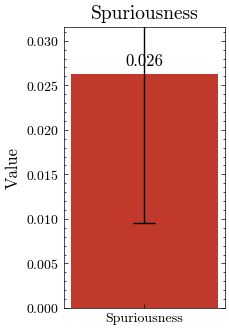

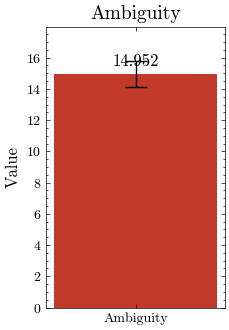

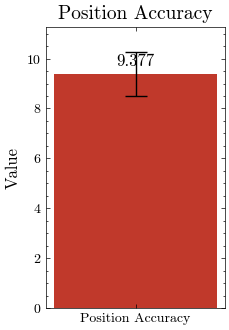

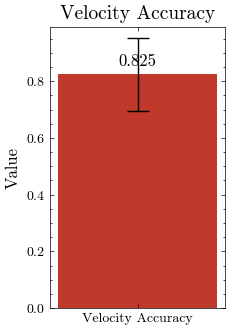

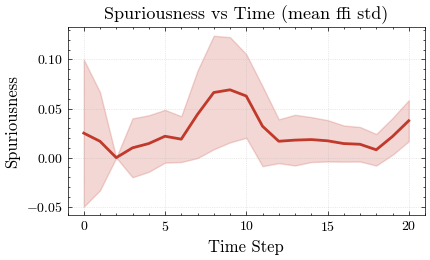

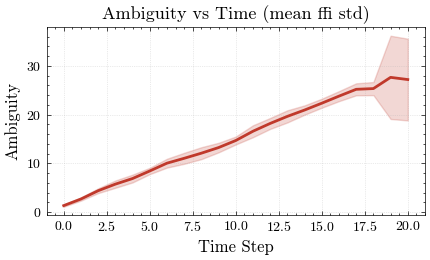

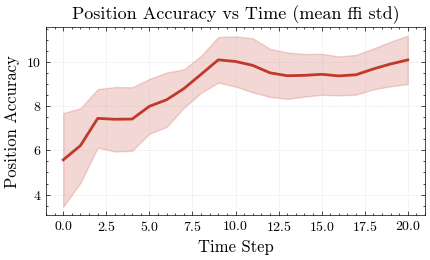

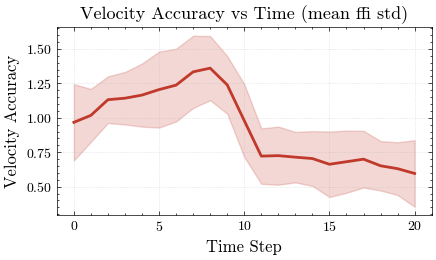

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

plt.style.use(['science', 'no-latex'])

def unpack(metrics):
    (spuriousness, ambiguity, completeness, pos_acc, vel_acc, 
     rate_track_change, longest_track, spurious_at_t, ambiguity_at_t, 
     complete_at_t, pos_acc_at_t, vel_acc_at_t) = metrics
    return {
        "Spuriousness": spuriousness,
        "Ambiguity": ambiguity,
        "Position Accuracy": pos_acc,
        "Velocity Accuracy": vel_acc,
        "Spuriousness at times": spurious_at_t,
        "Ambiguity at times": ambiguity_at_t,
        "Position Accuracy at times": pos_acc_at_t,
        "Velocity Accuracy at times": vel_acc_at_t
    }

num_steps = 20
seeds = range(10)
scalar_keys = [
    "Spuriousness", "Ambiguity", "Position Accuracy", "Velocity Accuracy"
]
time_keys = [
    "Spuriousness at times", "Ambiguity at times", "Position Accuracy at times", "Velocity Accuracy at times"
]

# Storage for metrics
scalar_vals = {key: [] for key in scalar_keys}
time_vals = {key: [] for key in time_keys}

for seed in seeds:
    idver = generate_siap_metrics(seed, num_steps=num_steps)
    id_metrics = unpack(idver)
    for key in scalar_keys:
        scalar_vals[key].append(id_metrics[key])
    for key in time_keys:
        ts = id_metrics[key]
        # Ensure ts is a list of floats
        vals = [float(x.value) if hasattr(x, 'value') else float(x) for x in ts]
        time_vals[key].append(vals)

# Plot mean scalars
for key in scalar_keys:
    vals = np.array(scalar_vals[key])
    mean_val = vals.mean()
    std_val = vals.std()
    plt.figure(figsize=(2.5, 3.5))
    plt.bar([key], [mean_val], color='#C0392B', width=0.6, yerr=[std_val], capsize=8)
    plt.title(f"{key}", fontsize=14, fontweight='bold')
    plt.ylabel("Value", fontsize=12)
    plt.ylim(0, mean_val*1.2 if mean_val > 0 else 1)
    plt.text(0, mean_val + 0.02*(mean_val if mean_val>0 else 1), f"{mean_val:.3f}", ha='center', va='bottom', fontsize=12)
    plt.tight_layout()
    plt.show()

# Plot mean time series
for key in time_keys:
    arr = np.array(time_vals[key])
    if arr.size == 0:
        continue
    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0)
    times = np.arange(len(mean))
    plt.figure(figsize=(4.5, 2.8))
    plt.plot(times, mean, color='#C0392B', linewidth=2, label='Mean')
    plt.fill_between(times, mean-std, mean+std, color='#C0392B', alpha=0.2, label='Std Dev')
    plt.xlabel("Time Step", fontsize=12)
    plt.ylabel(key.replace(" at times", ""), fontsize=12)
    plt.title(f"{key.replace(' at times','')} vs Time (mean ± std)", fontsize=13, fontweight='bold')
    plt.grid(linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()
